<h1 style="text-align: center;">Model Interpretation</h1>
<h3 style="text-align: center;">Hotel Booking Cancellation Prediction</h3>

---

<h5 style="text-align: right;">By Beta Group</h5>

## Goal
Notebook ini membedah model final yang sudah dipilih & disimpan, yaitu model XGBoost, supaya bisa menjawab: *model ini sebenarnya belajar pola apa, dan seberapa bisa dipercaya pola itu?*

## Alur
1. Ambil model (load dari `../final_model/XGBoost.pkl`)
2. Mencari tau parameter yang digunakan
3. Interpretasi model (built-in feature importance + permutation importance)
4. SHAP (global + local explanation)
5. Feature importance (rangkuman & ranking gabungan dari semua metode)

In [1]:
import warnings
warnings.filterwarnings("ignore")

## **Section 0. Setup & Configuration**

The following parameters control the entire training process in this notebook:

| Variable | Purpose |
|---|---|
| `RANDOM_STATE` | Random seed for reproducibility |
| `READ_CSV` | Path to the cleaned dataset |
| `SHAP_SAMPLE_SIZE` | Max number of `x_train` rows sampled for SHAP value computation, to keep runtime and plots manageable |
| `TOP_N_FEATURES` | Number of top-ranked features shown in each importance plot/table |

In [2]:
RANDOM_STATE = 42
READ_CSV = "../data/hotel_booking_2017_cleaned.csv"
MODEL_DIR = "../final_model/"

SHAP_SAMPLE_SIZE = 2000
TOP_N_FEATURES = 20      

## **0.1 Import Libraries**

In [3]:
import os
import glob

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import shap

## **0.2 Load Dataset**

Loads the dataset produced by the earlier cleaning step (`hotel_booking_2017_cleaned.csv`).

In [4]:
df = pd.read_csv(READ_CSV)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,has_babies,is_family,total_stay_nights,has_agent,has_company,total_previous_bookings,previous_cancellation_rate,has_previous_cancellation,has_booking_changes,room_type_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,0,0,0,0,0.0,0,1,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,0,0,0,0,0.0,0,1,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,1,0,0,0,0.0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,1,1,0,0,0.0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,0,2,1,0,0,0.0,0,0,0


# **Section 1. Load Model**

## **1.1 Load model final**

In [5]:
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pkl"))
print("File model ditemukan:")
for f in model_files:
    print(" -", f)

assert len(model_files) >= 1, f"Tidak ada file .pkl di {MODEL_DIR}."

# Kalau cuma ada 1 file, langsung dipakai. Kalau lebih dari 1, GANTI index ini manual.
MODEL_PATH = model_files[0]
print("\nModel yang dipakai:", MODEL_PATH)

final_model = joblib.load(MODEL_PATH)
final_model

File model ditemukan:
 - ../final_model/XGBoost.pkl

Model yang dipakai: ../final_model/XGBoost.pkl


,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('normal_numeric_pipeline', ...), ('skewed_numeric_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## **1.2 Reload Data & Reconstruct Train/Test Split**

Split-nya berdasarkan tahun, supaya nomor baris & interpretasi konsisten dengan apa yang model sebenarnya lihat saat training/testing.

In [6]:
train_df = df[df["arrival_date_year"] == 2015].copy()
val_df   = df[df["arrival_date_year"] == 2016].copy()
test_df  = df[df["arrival_date_year"] == 2017].copy()

x_train = train_df.drop(columns=["is_canceled"])
y_train = train_df["is_canceled"]

x_val = val_df.drop(columns=["is_canceled"])
y_val = val_df["is_canceled"]

x_test = test_df.drop(columns=["is_canceled"])
y_test = test_df["is_canceled"]

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")

Train      : 21,965
Validation : 56,621
Test       : 40,619


## **1.3 Sanity Check**

Sebelum masuk ke interpretasi, cek ulang ROC-AUC di train & test. Kalau angkanya jauh beda dari yang tercatat di model setelah *Tuning*, berarti ada yang salah (file model kebalik, data beda versi, dll). Interpretasi model yang salah load itu lebih berbahaya daripada tidak ada interpretasi sama sekali.

In [7]:
train_proba = final_model.predict_proba(x_train)[:, 1]
test_proba = final_model.predict_proba(x_test)[:, 1]

print(f"ROC-AUC train : {roc_auc_score(y_train, train_proba):.4f}")
print(f"ROC-AUC test  : {roc_auc_score(y_test, test_proba):.4f}")

ROC-AUC train : 0.9670
ROC-AUC test  : 0.8861


### Overfitting pada Model Final

Hasil *sanity check* menunjukkan **ROC-AUC train = 0.9449** dan **ROC-AUC test = 0.8861**, dengan selisih sekitar **0.06 poin**. Angka train di sini adalah gabungan 2015+2016, jadi belum jelas apakah gap ini murni disebabkan kompleksitas model (overfitting klasik) atau ada faktor lain. Breakdown ROC-AUC per tahun individual (2015, 2016, 2017) dilakukan di bawah untuk menjawab pertanyaan ini sebelum menarik kesimpulan.

Hyperparameter classifier final relevan untuk menjelaskan gap ini:

- `max_depth=3` — pohon dangkal, membatasi kompleksitas tiap estimator individual.
- `n_estimators=400` dengan `learning_rate=0.08` — banyak pohon dengan langkah kecil (*shrinkage*).
- `reg_alpha=5` dan `reg_lambda=2` — regularisasi L1/L2 pada bobot daun.
- `subsample=0.7` dan `colsample_bytree=0.8` — subsampling baris dan kolom per pohon.
- `min_child_weight=5` — mencegah split pada leaf dengan jumlah sample terlalu sedikit.
- `scale_pos_weight=1.7` — menyesuaikan bobot kelas positif untuk ketidakseimbangan `is_canceled`.

In [8]:
year_splits = {
    2015: train_df,
    2016: val_df,
    2017: test_df
}

roc_auc_per_year = {}

for year, df_year in year_splits.items():
    x_year = df_year.drop(columns=["is_canceled"])
    y_year = df_year["is_canceled"]

    proba_year = final_model.predict_proba(x_year)[:, 1]
    auc_year = roc_auc_score(y_year, proba_year)
    roc_auc_per_year[year] = auc_year

    print(f"ROC-AUC {year} (n={len(df_year):,}): {auc_year:.4f}")

ROC-AUC 2015 (n=21,965): 0.9670
ROC-AUC 2016 (n=56,621): 0.9352
ROC-AUC 2017 (n=40,619): 0.8861


### **Interpretasi: Concept Drift, Bukan Sekadar Overfitting**

Hasil breakdown performa berdasarkan tahun menunjukkan adanya pola penurunan ROC-AUC secara monoton, yaitu **0.9670 pada 2015**, **0.9352 pada 2016**, dan **0.8861 pada 2017**. Penurunan ini menunjukkan bahwa kemampuan model dalam membedakan reservasi yang akan dibatalkan dan tidak dibatalkan semakin menurun pada periode yang lebih baru.

Temuan yang penting adalah bahwa **2015 dan 2016 sama-sama digunakan dalam proses fitting `final_model`** sehingga keduanya merupakan data *in-sample*. Meskipun demikian, terdapat perbedaan ROC-AUC sekitar **0.03 poin** antara 2015 dan 2016. Jika penurunan performa pada sanity check sebelumnya hanya disebabkan oleh **overfitting klasik**, yaitu model terlalu menyesuaikan diri terhadap data training sehingga performanya menurun ketika menghadapi data yang belum pernah dilihat, performa pada 2015 dan 2016 seharusnya relatif lebih serupa karena keduanya termasuk dalam data yang digunakan untuk melakukan fitting model. Namun, performa yang lebih rendah pada 2016 menunjukkan bahwa terdapat perubahan pola bahkan di antara periode yang sama-sama digunakan dalam proses training.

Kondisi tersebut **mengindikasikan adanya komponen *concept drift***, yaitu perubahan hubungan antara karakteristik reservasi dan kemungkinan cancellation dari waktu ke waktu. Dalam konteks proyek ini, pola booking dan cancellation pada 2016 tampak mulai berbeda dari 2015, kemudian menunjukkan pergeseran yang lebih lanjut pada 2017. Penurunan performa dari 2015 → 2016 → 2017 juga memperkuat indikasi bahwa model menghadapi pola yang semakin berbeda ketika diterapkan pada periode yang lebih baru.

Dengan demikian, gap performa antara data training dan test tidak sebaiknya diinterpretasikan semata-mata sebagai **overfitting**. Hyperparameter regularisasi seperti `max_depth`, `reg_alpha`, `reg_lambda`, `subsample`, dan parameter terkait lainnya tetap diperlukan untuk mengendalikan overfitting klasik. Namun, regularisasi tidak dapat menghilangkan *concept drift* karena permasalahannya bukan hanya pada kompleksitas model, melainkan pada perubahan pola data dari waktu ke waktu.

Implikasinya, penerapan model dalam kondisi nyata perlu disertai **monitoring performa secara berkala** untuk mendeteksi penurunan kemampuan prediksi pada periode terbaru. Apabila performa mulai mengalami degradasi akibat perubahan pola booking atau cancellation, model perlu **diretrain secara berkala menggunakan data terbaru**. Dengan demikian, strategi pemeliharaan model tidak hanya bergantung pada tuning hyperparameter menggunakan data historis, tetapi juga mempertimbangkan perubahan karakteristik bisnis dan pola cancellation dari waktu ke waktu.

# **Section 2. Used Parameter**

## **2.1 Top-level Pipeline Structure**

`final_model` adalah imblearn `Pipeline`. Cek urutan step-nya dulu.

In [9]:
for step_name, step_obj in final_model.named_steps.items():
    print(f"[{step_name}] -> {type(step_obj).__name__}")

[preprocessor] -> ColumnTransformer
[feature_selection] -> SelectKBest
[sampler] -> RandomOverSampler
[classifier] -> XGBClassifier


## **2.2 Parameter Classifier**

Menampilkan hyperparameter apa yang akhirnya dipilih `RandomizedSearchCV` buat model klasifikasinya.

In [10]:
classifier = final_model.named_steps["classifier"]
print("Classifier:", type(classifier).__name__)
print()
for k, v in classifier.get_params().items():
    print(f"  {k:25s} : {v}")

Classifier: XGBClassifier

  objective                 : binary:logistic
  base_score                : None
  booster                   : None
  callbacks                 : None
  colsample_bylevel         : None
  colsample_bynode          : None
  colsample_bytree          : 0.8
  device                    : None
  early_stopping_rounds     : None
  enable_categorical        : True
  eval_metric               : None
  feature_types             : None
  feature_weights           : None
  gamma                     : None
  grow_policy               : None
  importance_type           : None
  interaction_constraints   : None
  learning_rate             : 0.08
  max_bin                   : None
  max_cat_threshold         : None
  max_cat_to_onehot         : None
  max_delta_step            : None
  max_depth                 : 3
  max_leaves                : None
  min_child_weight          : 5
  missing                   : nan
  monotone_constraints      : None
  multi_strategy         

## **2.3 Preprocessor Structure**

Identifikasi pembagian kolom `ColumnTransformer` ke dalam masing-masing pipeline serta metode preprocessing yang digunakan, meliputi encoder, scaler, dan imputer pada setiap sub-pipeline.

In [11]:
preprocessor = final_model.named_steps["preprocessor"]
for name, sub_pipeline, cols in preprocessor.transformers_:
    print(f"=== {name} ===")
    print(f"  Kolom ({len(cols) if hasattr(cols, '__len__') else '-'}): {cols}")
    if hasattr(sub_pipeline, "named_steps"):
        for step_name, step_obj in sub_pipeline.named_steps.items():
            if isinstance(step_obj, str):
                print(f"  [{step_name}] -> \"{step_obj}\" (passthrough, tidak ada transformasi)")
            else:
                print(f"  [{step_name}] -> {type(step_obj).__name__} | params: {step_obj.get_params()}")
    print()

=== normal_numeric_pipeline ===
  Kolom (8): ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'previous_cancellations', 'days_in_waiting_list']
  [scaler] -> MinMaxScaler | params: {'clip': False, 'copy': True, 'feature_range': (0, 1)}

=== skewed_numeric_pipeline ===
  Kolom (3): ['adults', 'previous_bookings_not_canceled', 'booking_changes']
  [transform] -> PowerTransformer | params: {'copy': True, 'method': 'yeo-johnson', 'standardize': True}
  [scaler] -> StandardScaler | params: {'copy': True, 'with_mean': True, 'with_std': True}

=== low_variance_numeric_pipeline ===
  Kolom (4): ['children', 'babies', 'required_car_parking_spaces', 'total_of_special_requests']
  [scaler] -> StandardScaler | params: {'copy': True, 'with_mean': True, 'with_std': True}

=== categorical_ohe_pipeline ===
  Kolom (18): ['hotel', 'arrival_date_year', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', '

### Keterbatasan Penamaan Fitur pada `TargetEncoder`

`categorical_high_cardinal_pipeline` menerima 4 kolom dengan urutan tetap: `arrival_date_month` (indeks 0), `country` (indeks 1), `assigned_room_type` (indeks 2), `company` (indeks 3), yang diproses dengan `TargetEncoder` dari library `category_encoders`.

Pada hasil `get_feature_names_out()`, keempat kolom ini **tidak** kembali dengan nama aslinya, melainkan sebagai indeks posisi generik. Ini merupakan keterbatasan teknis dari implementasi `get_feature_names_out()` pada `TargetEncoder` versi yang digunakan.

Berdasarkan urutan kolom di atas, `categorical_high_cardinal_pipeline__1` kemungkinan besar
merujuk pada fitur **`country`**.

**Rekomendasi perbaikan**: beri nama kolom secara eksplisit sebelum encoding, atau override `get_feature_names_out()` pada custom transformer, supaya hasil SHAP/feature importance tidak ambigu saat dipresentasikan.

## **2.4 Feature Selection & Sampler Step**

Evaluasi konfigurasi `feature_selection` untuk mengidentifikasi apakah menggunakan metode seleksi fitur seperti SelectKBest atau SelectFdr, maupun "passthrough". Selain itu, identifikasi sampler yang digunakan pada proses training, dengan memperhatikan bahwa sampler hanya diterapkan saat `.fit()` dan tidak digunakan pada `.predict()`.

In [12]:
fs_step = final_model.named_steps["feature_selection"]
sampler_step = final_model.named_steps["sampler"]

print("feature_selection:", fs_step if isinstance(fs_step, str) else f"{type(fs_step).__name__} | params: {fs_step.get_params()}")
print("sampler          :", sampler_step if isinstance(sampler_step, str) else f"{type(sampler_step).__name__} | params: {sampler_step.get_params()}")

feature_selection: SelectKBest | params: {'k': 15, 'score_func': <function f_classif at 0x315d8c2c0>}
sampler          : RandomOverSampler | params: {'random_state': 42, 'sampling_strategy': 'auto', 'shrinkage': None}


## **2.5 Model Summary**

Kompilasi seluruh temuan ke dalam satu tabel ringkas untuk memudahkan penyajian pada slide atau laporan tanpa perlu merujuk kembali ke bagian sebelumnya.

In [13]:
recipe = {
    "classifier": type(classifier).__name__,
    "n_features_in_preprocessor": sum(len(cols) for _, _, cols in preprocessor.transformers_ if hasattr(cols, "__len__")),
    "feature_selection": "passthrough" if isinstance(fs_step, str) else type(fs_step).__name__,
    "sampler_used_at_train": "passthrough" if isinstance(sampler_step, str) else type(sampler_step).__name__,
}

# ambil hyperparameter classifier yang paling sering jadi concern (kalau ada di model ini)
watch_params = ["n_estimators", "max_depth", "learning_rate", "min_samples_split",
                 "min_samples_leaf", "min_child_weight", "subsample", "colsample_bytree",
                 "max_features", "scale_pos_weight"]
for p in watch_params:
    if p in classifier.get_params():
        recipe[p] = classifier.get_params()[p]

pd.Series(recipe, name="value").to_frame()

,value
classifier,XGBClassifier
n_features_in_preprocessor,41
feature_selection,SelectKBest
sampler_used_at_train,RandomOverSampler
n_estimators,400
max_depth,3
learning_rate,0.08
min_child_weight,5
subsample,0.7
colsample_bytree,0.8


# **Section 3. Model Interpretation**

## **3.1 Get the Final Feature Names**

Gunakan `ColumnTransformer.get_feature_names_out()` untuk memperoleh nama fitur yang sesuai dengan struktur preprocessor yang sebenarnya digunakan, sehingga terhindar dari ketidaksesuaian akibat hardcode atau asumsi manual. Apabila `feature_selection` aktif, lakukan penyaringan nama fitur berdasarkan hasil `get_support()`.

In [14]:
def get_final_feature_names(pipeline):
    preproc = pipeline.named_steps["preprocessor"]
    try:
        names = preproc.get_feature_names_out()
    except Exception as e:
        # fallback kalau ada transformer (mis. versi lama category_encoders) yang belum
        # support get_feature_names_out()
        print(f"[WARNING] get_feature_names_out() gagal: {e}. Pakai nama generik sebagai fallback.")
        n_out = preproc.transform(x_train.head(1)).shape[1]
        names = np.array([f"feature_{i}" for i in range(n_out)])

    fs = pipeline.named_steps["feature_selection"]
    if not isinstance(fs, str):
        mask = fs.get_support()
        names = names[mask]

    return names

final_feature_names = get_final_feature_names(final_model)
print(f"Jumlah fitur final yang benar-benar masuk ke classifier: {len(final_feature_names)}")
final_feature_names[:20]

Jumlah fitur final yang benar-benar masuk ke classifier: 15


array(['normal_numeric_pipeline__lead_time',
       'normal_numeric_pipeline__previous_cancellations',
       'skewed_numeric_pipeline__booking_changes',
       'low_variance_numeric_pipeline__required_car_parking_spaces',
       'low_variance_numeric_pipeline__total_of_special_requests',
       'categorical_ohe_pipeline__hotel_Resort Hotel',
       'categorical_ohe_pipeline__market_segment_Direct',
       'categorical_ohe_pipeline__market_segment_Groups',
       'categorical_ohe_pipeline__distribution_channel_Direct',
       'categorical_ohe_pipeline__distribution_channel_TA/TO',
       'categorical_ohe_pipeline__deposit_type_Non Refund',
       'categorical_ohe_pipeline__room_type_changed_1',
       'categorical_ohe_pipeline__country_PRT',
       'categorical_ohe_pipeline__assigned_room_type_D',
       'categorical_high_cardinal_pipeline__agent'], dtype=object)

## **3.2 Built-in Feature Importance (`feature_importances_`)**

Model final adalah **XGBoost** (`XGBClassifier`), model tree-based, sehingga menggunakan `feature_importances_` bawaan pada ruang fitur setelah preprocessing.

Secara default, `feature_importances_` pada XGBoost dihitung berdasarkan **gain** (rata-rata peningkatan performa split yang melibatkan fitur tersebut), sehingga nilainya sudah bisa dibandingkan langsung antar-fitur tanpa perlu penyesuaian skala seperti pada model linear. Metrik ini tetap bisa bias terhadap fitur dengan kardinalitas tinggi.

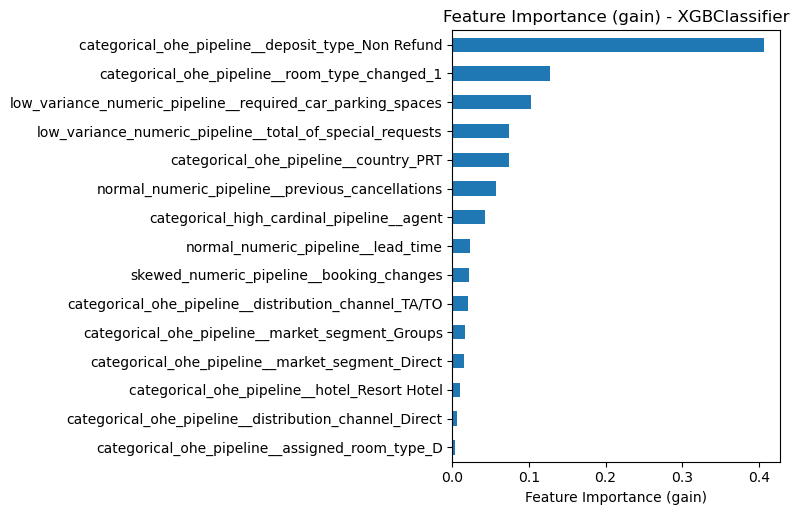

categorical_ohe_pipeline__deposit_type_Non Refund             0.407291
categorical_ohe_pipeline__room_type_changed_1                 0.127045
low_variance_numeric_pipeline__required_car_parking_spaces    0.103045
low_variance_numeric_pipeline__total_of_special_requests      0.074074
categorical_ohe_pipeline__country_PRT                         0.073634
normal_numeric_pipeline__previous_cancellations               0.057145
categorical_high_cardinal_pipeline__agent                     0.042476
normal_numeric_pipeline__lead_time                            0.023024
skewed_numeric_pipeline__booking_changes                      0.021520
categorical_ohe_pipeline__distribution_channel_TA/TO          0.019902
categorical_ohe_pipeline__market_segment_Groups               0.015802
categorical_ohe_pipeline__market_segment_Direct               0.015311
categorical_ohe_pipeline__hotel_Resort Hotel                  0.010136
categorical_ohe_pipeline__distribution_channel_Direct         0.005840
catego

In [15]:
assert hasattr(classifier, "feature_importances_"), (
    "Classifier ini tidak punya feature_importances_. Section ini didesain untuk model tree-based (mis. XGBoost, RandomForest). "
    "Kalau model final ternyata linear, kembalikan ke coef_."
)

builtin_importance = pd.Series(
    classifier.feature_importances_,
    index=final_feature_names
).sort_values(ascending=False)

top_builtin = builtin_importance.head(TOP_N_FEATURES)

plt.figure(figsize=(8, max(4, 0.35 * len(top_builtin))))
top_builtin.iloc[::-1].plot(kind="barh")
plt.title(f"Feature Importance (gain) - {type(classifier).__name__}")
plt.xlabel("Feature Importance (gain)")
plt.tight_layout()
plt.show()

top_builtin

### Catatan Kritis Mengenai Importance Berbasis `feature_importances_`

`feature_importances_` pada XGBoost punya keterbatasan yang perlu diperhatikan sebelum dipakai sebagai dasar klaim bisnis.

* **Tidak sensitif terhadap skala fitur**

  Importance berbasis gain tidak dipengaruhi oleh skala numerik antar-fitur, sehingga perbandingan magnitude antara fitur numerik dan hasil encoding kategorikal lebih langsung dibandingkan pada model linear.

* **Bias terhadap fitur dengan kardinalitas tinggi**

  Fitur dengan banyak kemungkinan nilai split (misalnya hasil `TargetEncoder` pada `agent` atau `country`) cenderung mendapat importance lebih tinggi hanya karena lebih sering menjadi kandidat split, bukan semata karena pengaruh bisnisnya lebih besar.

* **Rentan terhadap multikolinearitas**

  Kalau dua fitur saling berkorelasi tinggi, pohon bisa memilih salah satu secara tidak konsisten di tiap split, sehingga importance-nya terbagi tidak stabil antar keduanya.

* **Tidak punya arah/tanda**

  `feature_importances_` hanya mengukur besar kontribusi terhadap split, tanpa menunjukkan apakah fitur meningkatkan atau menurunkan probabilitas cancellation. Arah pengaruh perlu dianalisis lewat SHAP.

Mengingat keterbatasan tersebut, hasil `feature_importances_` selanjutnya dibandingkan dengan **Permutation Importance**, yang mengevaluasi kontribusi fitur berdasarkan penurunan performa aktual pada data test, independen dari struktur internal model.

## **3.3 Permutation Importance**

Permutation Importance mengukur kontribusi suatu fitur dengan cara mengacak nilai pada satu kolom fitur sehingga hubungan antara fitur tersebut dan target menjadi terganggu, kemudian mengukur seberapa besar penurunan skor performa model.

Metode ini bersifat **model-agnostic** dan dihitung menggunakan **test set**, sehingga memberikan gambaran yang lebih representatif mengenai kontribusi fitur terhadap kemampuan generalisasi model dibandingkan built-in feature importance yang bergantung pada struktur internal model saat training.

Perlu diperhatikan bahwa Permutation Importance dihitung pada **level input pipeline (`x_test` mentah)**, bukan pada level fitur yang telah melalui proses encoding atau transformasi lainnya. Hal ini karena `permutation_importance` mengevaluasi keseluruhan pipeline sebagai satu kesatuan.

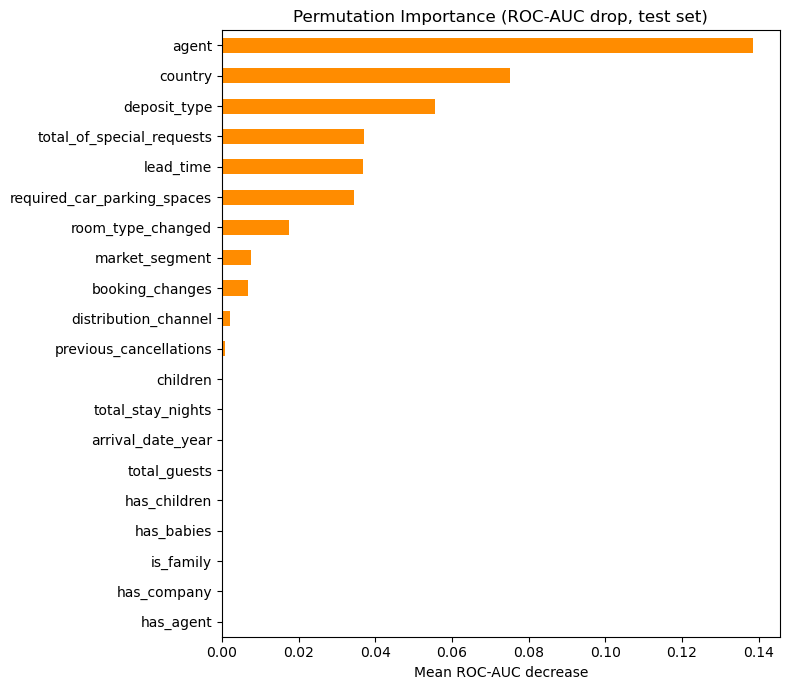

agent                          0.138629
country                        0.075233
deposit_type                   0.055697
total_of_special_requests      0.037006
lead_time                      0.036914
required_car_parking_spaces    0.034582
room_type_changed              0.017524
market_segment                 0.007720
booking_changes                0.006821
distribution_channel           0.002237
previous_cancellations         0.000942
children                       0.000000
total_stay_nights              0.000000
arrival_date_year              0.000000
total_guests                   0.000000
has_children                   0.000000
has_babies                     0.000000
is_family                      0.000000
has_company                    0.000000
has_agent                      0.000000
dtype: float64

In [16]:
perm_result = permutation_importance(
    final_model,
    x_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=x_test.columns
).sort_values(ascending=False)

top_perm = perm_importance.head(TOP_N_FEATURES)

plt.figure(figsize=(8, max(4, 0.35 * len(top_perm))))
top_perm.iloc[::-1].plot(kind="barh", color="darkorange")
plt.title("Permutation Importance (ROC-AUC drop, test set)")
plt.xlabel("Mean ROC-AUC decrease")
plt.tight_layout()
plt.show()

top_perm

### Perbedaan antara Built-in Feature Importance dan Permutation Importance

Perbedaan peringkat fitur antara `feature_importances_` dan Permutation Importance biasanya disebabkan oleh **multikolinearitas**, **bias terhadap fitur berkardinalitas tinggi** (encoding dengan banyak kategori), atau **fragmentasi akibat One-Hot Encoding**.

Apabila suatu fitur memiliki `feature_importances_` (dan/atau SHAP importance) yang tinggi tetapi mengalami penurunan peringkat signifikan pada Permutation Importance, hal ini mengindikasikan bahwa kontribusi fitur tersebut terhadap **kemampuan generalisasi model** (diukur pada test set) lebih rendah daripada yang tersirat dari importance bawaannya saja, misalnya karena fitur tersebut sangat prediktif pada distribusi training tapi polanya tidak sepenuhnya bertahan pada test set.

Sebaliknya, fitur yang menunjukkan importance tinggi dan konsisten pada kedua metode memiliki bukti yang lebih kuat untuk dianggap relevan terhadap performa model dan lebih layak dipertimbangkan sebagai dasar **business insight**.

# **Section 4. SHAP**

## **4.1 Data Transformation into a Numeric Representation Used by the Classifier**

SHAP memerlukan input dalam bentuk numerik, yaitu data yang telah melalui tahap **preprocessing** dan **feature selection**, bukan *raw dataframe*. Oleh karena itu, data perlu ditransformasikan terlebih dahulu ke representasi numerik yang benar-benar diterima oleh classifier.

Pada analisis ini, digunakan **sample dari `x_train`** sebagai data yang akan dijelaskan. Penggunaan `x_train` dipilih karena `x_test` hanya mencakup data tahun 2017 dengan jumlah observasi yang lebih terbatas.

In [17]:
def transform_to_model_input(pipeline, X):
    X_transformed = pipeline.named_steps["preprocessor"].transform(X)
    fs = pipeline.named_steps["feature_selection"]
    if not isinstance(fs, str):
        X_transformed = fs.transform(X_transformed)
    return pd.DataFrame(X_transformed, columns=get_final_feature_names(pipeline), index=X.index)

# sample buat efisiensi
sample_idx = x_train.sample(
    n=min(SHAP_SAMPLE_SIZE, len(x_train)),
    random_state=RANDOM_STATE
).index

X_shap_input = transform_to_model_input(final_model, x_train.loc[sample_idx])
X_shap_input.shape

(2000, 15)

## **4.2 Building `TreeExplainer` and Calculating SHAP Values**

Karena model final adalah **XGBoost** (model tree-based), SHAP value dihitung menggunakan `shap.TreeExplainer`. `TreeExplainer` memanfaatkan struktur pohon secara langsung untuk menghitung SHAP value secara eksak, sehingga hasilnya presisi dan tetap cepat meskipun modelnya non-linear.

`TreeExplainer` tidak wajib menggunakan data referensi untuk masking. Secara default ia memakai pendekatan *tree_path_dependent* yang menelusuri distribusi data training langsung dari struktur pohon, tanpa perlu background dataset eksplisit.

In [18]:
explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(X_shap_input)

# TreeExplainer pada binary classifier umumnya mengembalikan array 2D (n_samples, n_features)
# yang sudah merepresentasikan kontribusi terhadap kelas positif (is_canceled=1) secara langsung.
# Guard ini tetap dipasang untuk jaga-jaga kalau versi shap tertentu mengembalikan bentuk lain
# (list per kelas atau array 3D).
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif np.asarray(shap_values).ndim == 3:
    shap_values_positive = np.asarray(shap_values)[:, :, 1]
else:
    shap_values_positive = shap_values

print("Shape SHAP values (kelas positif / is_canceled=1):", shap_values_positive.shape)

Shape SHAP values (kelas positif / is_canceled=1): (2000, 15)


## **4.3 Summary Plot (Beeswarm)**

Summary plot berbentuk **beeswarm** digunakan untuk memberikan gambaran global mengenai kontribusi setiap fitur terhadap prediksi model.

- **Setiap titik** merepresentasikan satu observasi (*booking*).
- **Posisi horizontal** menunjukkan nilai SHAP atau besarnya kontribusi fitur terhadap prediksi:
  - Semakin ke **kanan**, fitur semakin mendorong model untuk memprediksi **cancellation**.
  - Semakin ke **kiri**, fitur semakin mendorong model untuk memprediksi **tidak cancellation**.
- **Warna titik** merepresentasikan nilai asli dari fitur:
  - **Merah** menunjukkan nilai fitur yang relatif tinggi.
  - **Biru** menunjukkan nilai fitur yang relatif rendah.

Dengan demikian, beeswarm plot tidak hanya menunjukkan **seberapa besar kontribusi suatu fitur**, tetapi juga membantu mengidentifikasi **bagaimana nilai fitur tersebut berkaitan dengan arah prediksi model**.

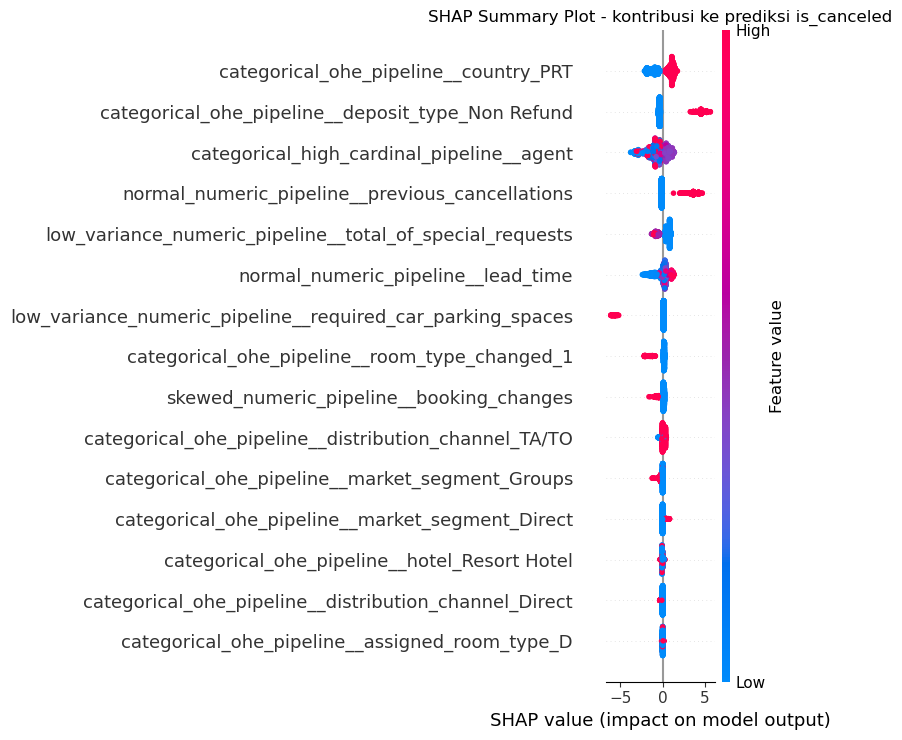

In [19]:
shap.summary_plot(shap_values_positive, X_shap_input, max_display=TOP_N_FEATURES, show=False)
plt.title("SHAP Summary Plot - kontribusi ke prediksi is_canceled")
plt.tight_layout()
plt.show()

## **4.4 Bar Plot — Mean |SHAP Value| by Fitur**

Bar plot digunakan untuk menampilkan **rata-rata nilai absolut SHAP (`mean |SHAP value|`)** dari setiap fitur. Nilai ini merepresentasikan besarnya kontribusi suatu fitur terhadap prediksi model secara keseluruhan, tanpa mempertimbangkan arah pengaruhnya.

Fitur dengan nilai `mean |SHAP value|` yang lebih tinggi memiliki kontribusi yang lebih besar terhadap prediksi model dan akan menempati peringkat yang lebih tinggi. Namun, karena nilai SHAP yang digunakan telah diabsolutkan, plot ini **tidak menunjukkan apakah suatu fitur meningkatkan atau menurunkan probabilitas cancellation**. Arah pengaruh perlu dianalisis menggunakan SHAP summary plot atau metode interpretasi lainnya.

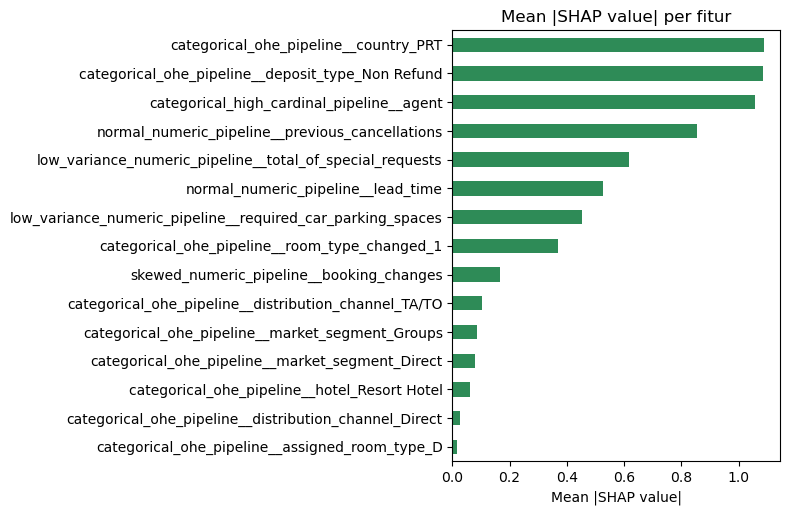

categorical_ohe_pipeline__country_PRT                         1.090532
categorical_ohe_pipeline__deposit_type_Non Refund             1.086990
categorical_high_cardinal_pipeline__agent                     1.056857
normal_numeric_pipeline__previous_cancellations               0.855934
low_variance_numeric_pipeline__total_of_special_requests      0.616361
normal_numeric_pipeline__lead_time                            0.526222
low_variance_numeric_pipeline__required_car_parking_spaces    0.453092
categorical_ohe_pipeline__room_type_changed_1                 0.368819
skewed_numeric_pipeline__booking_changes                      0.164836
categorical_ohe_pipeline__distribution_channel_TA/TO          0.101689
categorical_ohe_pipeline__market_segment_Groups               0.085030
categorical_ohe_pipeline__market_segment_Direct               0.077536
categorical_ohe_pipeline__hotel_Resort Hotel                  0.060482
categorical_ohe_pipeline__distribution_channel_Direct         0.025886
catego

In [20]:
shap_importance = pd.Series(
    np.abs(shap_values_positive).mean(axis=0),
    index=X_shap_input.columns
).sort_values(ascending=False)

top_shap = shap_importance.head(TOP_N_FEATURES)

plt.figure(figsize=(8, max(4, 0.35 * len(top_shap))))
top_shap.iloc[::-1].plot(kind="barh", color="seagreen")
plt.title("Mean |SHAP value| per fitur")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

top_shap

## **4.5 Dependence Plot for Top Features**

Dependence plot digunakan untuk menganalisis hubungan antara **nilai suatu fitur** dan **kontribusi SHAP** terhadap prediksi model. Visualisasi ini membantu mengidentifikasi **arah dan pola pengaruh fitur**, yang tidak dapat dijelaskan hanya melalui built-in feature importance.

Daftar `features_to_check` perlu disesuaikan dengan fitur-fitur teratas. Perlu diperhatikan bahwa nama fitur dapat berbeda tergantung pada konfigurasi dan encoder yang terpilih dalam proses *model search*.

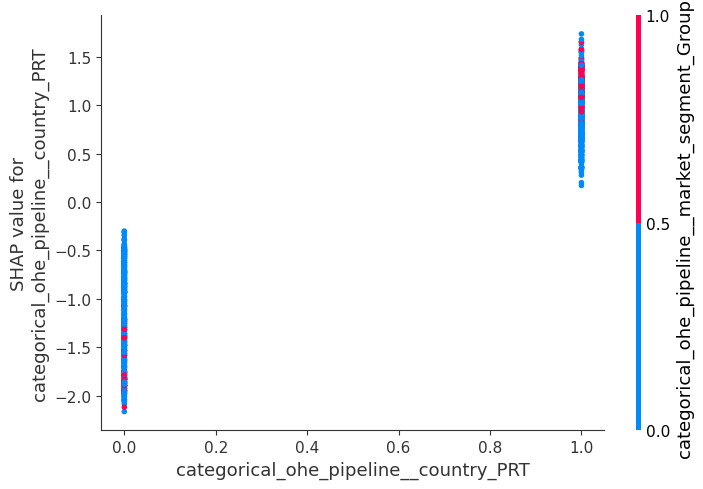

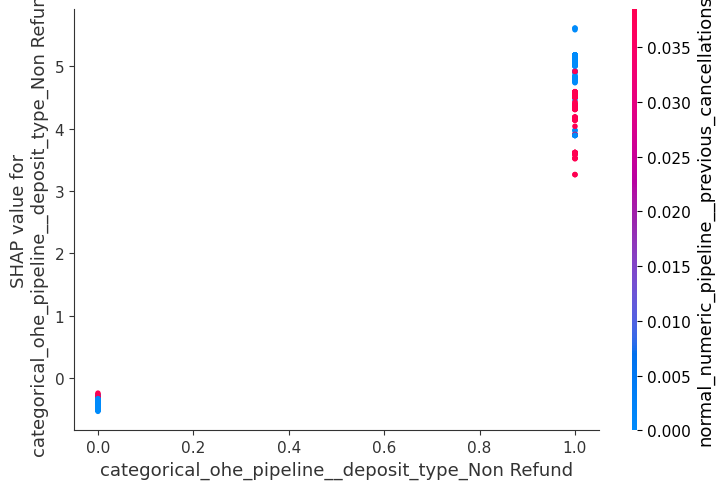

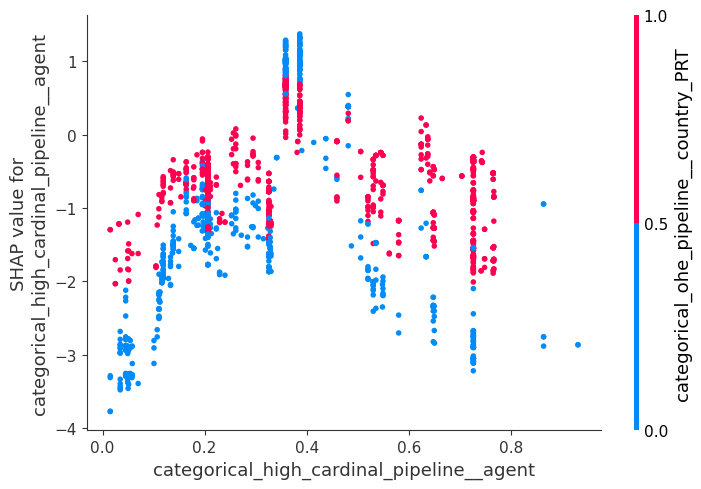

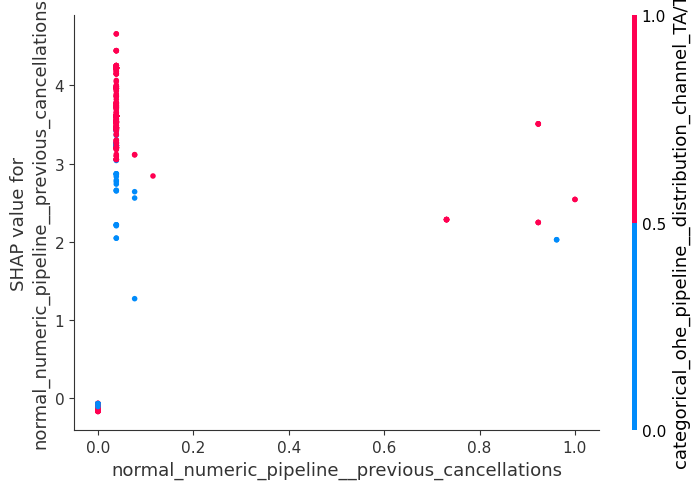

In [21]:
features_to_check = list(top_shap.index[:4])

for feat in features_to_check:
    shap.dependence_plot(feat, shap_values_positive, X_shap_input, show=False)
    plt.tight_layout()
    plt.show()

## **4.6 Local Explanation**

Analisis global memberikan gambaran umum mengenai kontribusi fitur terhadap prediksi model, tetapi belum menjelaskan **alasan di balik prediksi pada satu booking tertentu**. Untuk kebutuhan interpretasi pada kasus nyata, seperti menjelaskan kepada stakeholder mengapa suatu booking diprediksi akan mengalami cancellation, diperlukan analisis lokal menggunakan **waterfall plot** pada tingkat observasi.

Pada analisis ini, digunakan dua contoh booking yang dianggap paling informatif:

1. **Booking dengan probabilitas cancellation tertinggi**, untuk menganalisis faktor-faktor yang paling kuat mendorong model menghasilkan prediksi cancellation.
2. **Booking dengan kesalahan prediksi terbesar (residual terbesar)**, untuk mengidentifikasi faktor-faktor yang berkontribusi terhadap prediksi yang paling jauh dari kondisi aktual.

Kedua kasus tersebut memberikan perspektif yang berbeda: kasus pertama membantu memahami **prediksi dengan tingkat keyakinan tertinggi**, sedangkan kasus kedua membantu mengevaluasi **potensi kelemahan atau keterbatasan model** pada observasi tertentu.


=== Confidence cancel tertinggi (row index: 76391) ===
Label asli (is_canceled): 1  |  Prediksi probabilitas cancel: 1.000


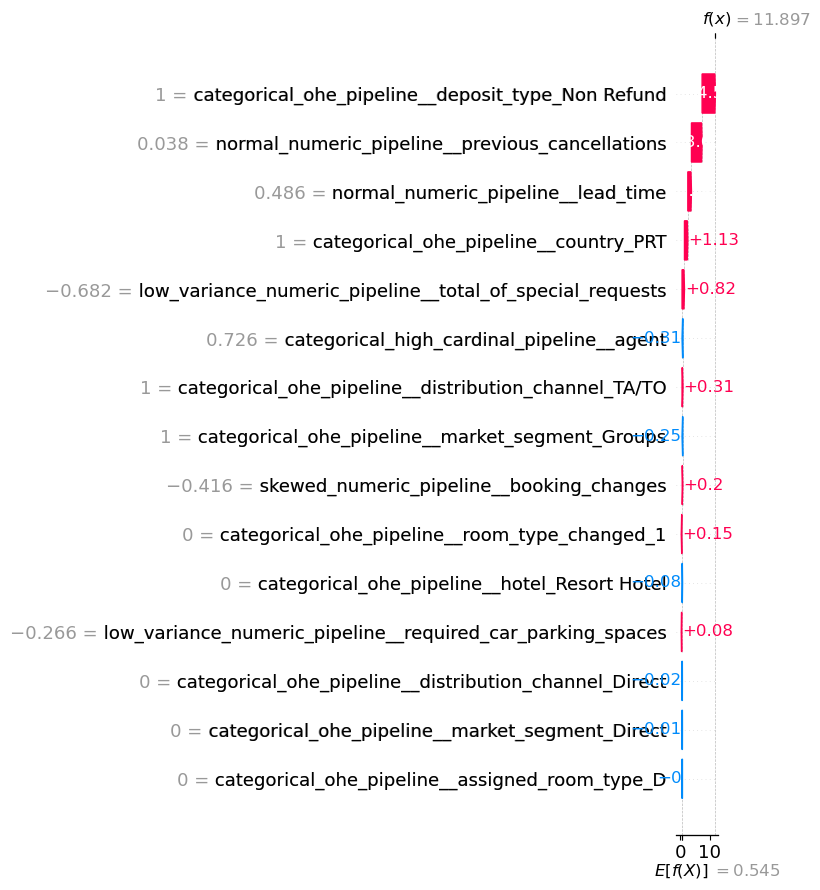


=== Prediksi paling meleset (row index: 41402) ===
Label asli (is_canceled): 1  |  Prediksi probabilitas cancel: 0.040


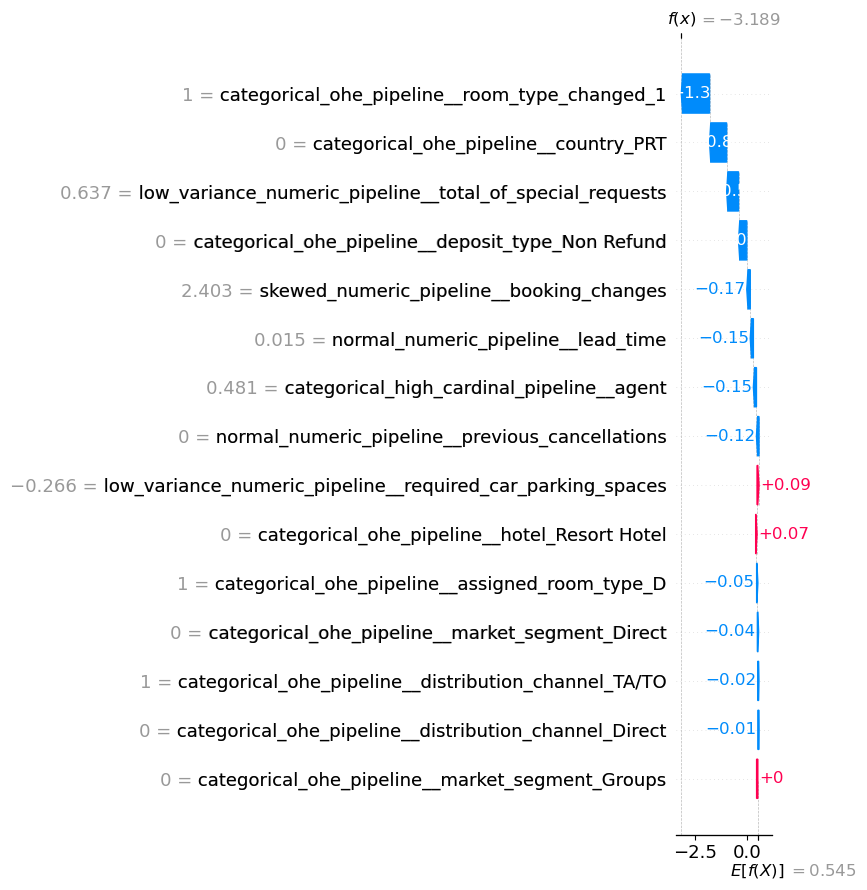

In [22]:
probas = final_model.predict_proba(x_train.loc[sample_idx])[:, 1]
probas_series = pd.Series(probas, index=sample_idx)

# kasus 1: prediksi cancel dengan confidence tertinggi
idx_highest_conf = probas_series.idxmax()

# kasus 2: model paling salah (prediksi jauh dari label asli)
residual = (probas_series - y_train.loc[sample_idx]).abs()
idx_most_wrong = residual.idxmax()

for label, idx in [("Confidence cancel tertinggi", idx_highest_conf), ("Prediksi paling meleset", idx_most_wrong)]:
    row_pos = X_shap_input.index.get_loc(idx)
    print(f"\n=== {label} (row index: {idx}) ===")
    print(f"Label asli (is_canceled): {y_train.loc[idx]}  |  Prediksi probabilitas cancel: {probas_series.loc[idx]:.3f}")

    explanation = shap.Explanation(
        values=shap_values_positive[row_pos],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_shap_input.iloc[row_pos].values,
        feature_names=X_shap_input.columns.tolist()
    )
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

# **Section 5. Feature Importance — Summary & Combined Ranking**

## **5.1 Combining Three Feature Importance Methods into a Single Table**

Tiga metode feature importance dibandingkan dalam satu tabel untuk memperoleh gambaran yang lebih komprehensif mengenai kontribusi fitur terhadap model.

**Built-in feature importance** dan **SHAP importance** dihitung pada ruang fitur **setelah preprocessing**, sehingga nama fitur dapat berbeda atau menjadi lebih panjang, terutama ketika menggunakan encoder seperti **One-Hot Encoding (OHE)** atau **Binary Encoding**. Sebaliknya, **Permutation Importance** dihitung pada ruang fitur **sebelum preprocessing**, sehingga menggunakan nama kolom asli.

Oleh karena itu, ketiga metode tersebut **tidak selalu dapat dipetakan secara langsung (1:1)** ketika satu kolom asli dipecah menjadi beberapa fitur hasil encoding. Penggabungan dilakukan berdasarkan **exact match** nama kolom apabila memungkinkan. Fitur yang tidak memiliki pasangan karena proses encoding ditampilkan secara terpisah dan **tidak dipaksakan untuk digabungkan tanpa mapping manual**.

Pendekatan ini menjaga integritas interpretasi dan menghindari kesimpulan yang keliru akibat penyamaan fitur yang sebenarnya tidak ekuivalen.

In [23]:
summary_table = pd.DataFrame({
    "builtin_importance": builtin_importance,
    "shap_importance": shap_importance,
}).fillna(0)

summary_table = summary_table.sort_values("shap_importance", ascending=False)

print("=== Ranking dari fitur hasil preprocessing (built-in vs SHAP) ===")
display(summary_table.head(TOP_N_FEATURES))

print("\n=== Ranking dari fitur asli / sebelum preprocessing (permutation importance) ===")
display(top_perm.to_frame("permutation_importance"))

=== Ranking dari fitur hasil preprocessing (built-in vs SHAP) ===


,builtin_importance,shap_importance
categorical_ohe_pipeline__country_PRT,0.073634,1.090532
categorical_ohe_pipeline__deposit_type_Non Refund,0.407291,1.086990
categorical_high_cardinal_pipeline__agent,0.042476,1.056857
normal_numeric_pipeline__previous_cancellations,0.057145,0.855934
low_variance_numeric_pipeline__total_of_special_requests,0.074074,0.616361
normal_numeric_pipeline__lead_time,0.023024,0.526222
low_variance_numeric_pipeline__required_car_parking_spaces,0.103045,0.453092
categorical_ohe_pipeline__room_type_changed_1,0.127045,0.368819
skewed_numeric_pipeline__booking_changes,0.021520,0.164836
categorical_ohe_pipeline__distribution_channel_TA/TO,0.019902,0.101689



=== Ranking dari fitur asli / sebelum preprocessing (permutation importance) ===


,permutation_importance
agent,0.138629
country,0.075233
deposit_type,0.055697
total_of_special_requests,0.037006
lead_time,0.036914
required_car_parking_spaces,0.034582
room_type_changed,0.017524
market_segment,0.007720
booking_changes,0.006821
distribution_channel,0.002237


## **5.2 Interpretation of Results**

Ranking pada tabel berikut diperoleh langsung dari output aktual `feature_importances_` pada XGBoost, SHAP, dan *Permutation Importance*. Ketiga metode digunakan secara bersamaan untuk melihat konsistensi kontribusi fitur dari perspektif yang berbeda: `feature_importances_` merefleksikan kontribusi fitur berdasarkan mekanisme *gain* pada model, SHAP mengukur kontribusi fitur terhadap prediksi secara lokal dan agregat, sedangkan *Permutation Importance* mengukur perubahan performa model ketika informasi pada suatu fitur diacak.

| Fitur (raw) | Rank Gain | Rank SHAP | Rank Permutation | Catatan |
|---|---:|---:|---:|---|
| `deposit_type` (Non Refund) | #1 (0.407) | #3 (0.949) | #3 (0.056) | Konsisten tinggi pada ketiga metode. Namun, tetap berstatus sebagai potensi **data leakage** karena kategori `Non Refund` memiliki *cancel rate* sebesar 94.6%. |
| `room_type_changed` | #2 (0.127) | #8 (0.345) | #7 (0.018) | Konsisten berada pada top-10. Namun, tetap berstatus sebagai potensi **data leakage** karena `assigned_room_type` dapat baru final mendekati waktu check-in. |
| `required_car_parking_spaces` | #3 (0.103) | #6 (0.394) | #6 (0.035) | Konsisten pada ketiga metode dan tidak terdapat indikasi leakage, sehingga merupakan kandidat yang relatif aman sebagai *business driver*. |
| `total_of_special_requests` | #4 (0.074) | #4 (0.642) | #4 (0.037) | Konsisten tinggi pada ketiga metode dan tidak terdapat indikasi leakage. |
| `country` | #5 (0.074) | #2 (1.031) | #2 (0.075) | Konsisten berada pada posisi tinggi di ketiga metode. |
| `previous_cancellations` | #6 (0.057) | #7 (0.352) | **#11 (0.0009, ~nol)** | Menunjukkan divergensi yang besar meskipun model telah menggunakan XGBoost. Temuan ini konsisten dengan indikasi leakage pada `previous_cancellation_rate` yang memiliki korelasi 0.898 dengan target. Oleh karena itu, fitur ini **belum layak dijadikan business driver**. |
| `agent` | #7 (0.042) | **#1 (1.111)** | **#1 (0.139)** | *Gain* relatif meremehkan fitur ini (rank #7), sedangkan SHAP dan *Permutation Importance* sama-sama menempatkannya pada posisi **#1**. Karena `agent` di-encode sebagai satu kolom menggunakan `TargetEncoder`, perbedaan ranking bukan disebabkan oleh fragmentasi *one-hot encoding*, melainkan menunjukkan perbedaan perspektif antar-metode dalam mengukur kontribusi fitur. |
| `lead_time` | #8 (0.023) | #5 (0.467) | #5 (0.037) | Konsisten menunjukkan kontribusi moderat hingga tinggi dan tidak terdapat indikasi leakage. |
| `booking_changes` | #9 (0.022) | #9 (0.151) | #9 (0.007) | Menunjukkan kontribusi yang relatif konsisten pada ketiga metode. Fitur ini dapat dipertimbangkan sebagai kandidat *business driver* tambahan. |

Fitur lainnya, yaitu `market_segment`, `distribution_channel`, `hotel`, dan `assigned_room_type`, berada pada ranking yang lebih rendah secara umum pada ketiga metode.

### **Kesimpulan Operasional**

Berdasarkan konsistensi antar-metode dan pemeriksaan terhadap potensi leakage, kandidat yang relatif paling aman untuk digunakan sebagai *business driver* adalah **`required_car_parking_spaces`, `total_of_special_requests`, `country`, `lead_time`, `agent`,** dan **`booking_changes`**. Keenam fitur tersebut menunjukkan kontribusi yang relatif konsisten, khususnya pada SHAP dan *Permutation Importance*, serta tidak memiliki indikasi leakage berdasarkan pemeriksaan yang dilakukan.

Sementara itu, **`deposit_type`** dan **`room_type_changed`** menunjukkan kontribusi yang tinggi dan konsisten pada ketiga metode, tetapi interpretasinya perlu disertai catatan mengenai potensi **data leakage**. Tingginya kontribusi kedua fitur tersebut menunjukkan bahwa informasi di dalamnya sangat membantu model dalam memprediksi cancellation, tetapi belum tentu merepresentasikan *business driver* yang tersedia secara valid pada saat reservasi dibuat.

Berbeda dengan fitur-fitur tersebut, **`previous_cancellations` tidak direkomendasikan sebagai business insight** sebelum divergensi antar-metode dapat diinvestigasi lebih lanjut. Fitur ini memiliki ranking relatif tinggi pada *gain* dan SHAP, tetapi hampir tidak memberikan dampak pada *Permutation Importance* di data test. Bersama dengan indikasi leakage pada `previous_cancellation_rate`, kondisi tersebut semakin memperkuat perlunya investigasi terhadap validitas sinyal yang dibawa oleh fitur-fitur terkait sebelum digunakan sebagai dasar pengambilan keputusan bisnis.

## **5.3 Export Results to CSV**

Hasil analisis feature importance dari berbagai metode diekspor ke dalam format **CSV** untuk memudahkan proses dokumentasi, analisis lanjutan, serta integrasi ke dalam laporan atau visualisasi eksternal.

In [24]:
os.makedirs("../reports", exist_ok=True)

summary_table.to_csv("../reports/feature_importance_summary.csv")
top_perm.to_frame("permutation_importance").to_csv("../reports/permutation_importance.csv")

print("Tersimpan di ../reports/")

Tersimpan di ../reports/
